In [2]:
import json
import numpy as np

fp = open("../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold0.8_K10_size1000.json")
data = json.load(fp)
fp.close()
fps = np.array(data["raw"]["pri_fusion_size"])
ex = np.array(data["raw"]["ex"])
ex_pub = np.array(data["raw"]["ex_pub"])
ex_pri = np.array(data["raw"]["ex_pri"])
f1 = np.array(data["raw"]["f1"])
f1_pub = np.array(data["raw"]["f1_pub"])
f1_pri = np.array(data["raw"]["f1_pri"])

In [ ]:
fps = fps.reshape(2, -1, 1000)
flops = fps.sum(-1) * 768

print(f"ex:\n {ex[1:].reshape(2, 5)}")
print(f"ex(%):\n {(ex / ex[0])[1:].reshape(2, -1).round(4) * 100}")
print(f"ex_pub(%):\n {(ex_pub / ex[0]).reshape(2, -1).round(4) * 100}")
print(f"ex_pri(%):\n {(ex_pri / ex[0]).reshape(2, -1).round(4) * 100}")

ex:
 [[0.409 0.392 0.389 0.403 0.411]
 [0.403 0.404 0.415 0.416 0.415]]
ex(%):
 [[97.85 93.78 93.06 96.41 98.33]
 [96.41 96.65 99.28 99.52 99.28]]
ex_pub(%):
 [[95.93 86.36 75.84 57.18 32.78]
 [95.93 86.36 75.84 57.18 32.78]]
ex_pri(%):
 [[32.06 61.96 82.78 89.95 96.65]
 [32.3  67.7  87.08 93.06 98.33]]


[0.73 2.45 6.36 5.38 0.  ]


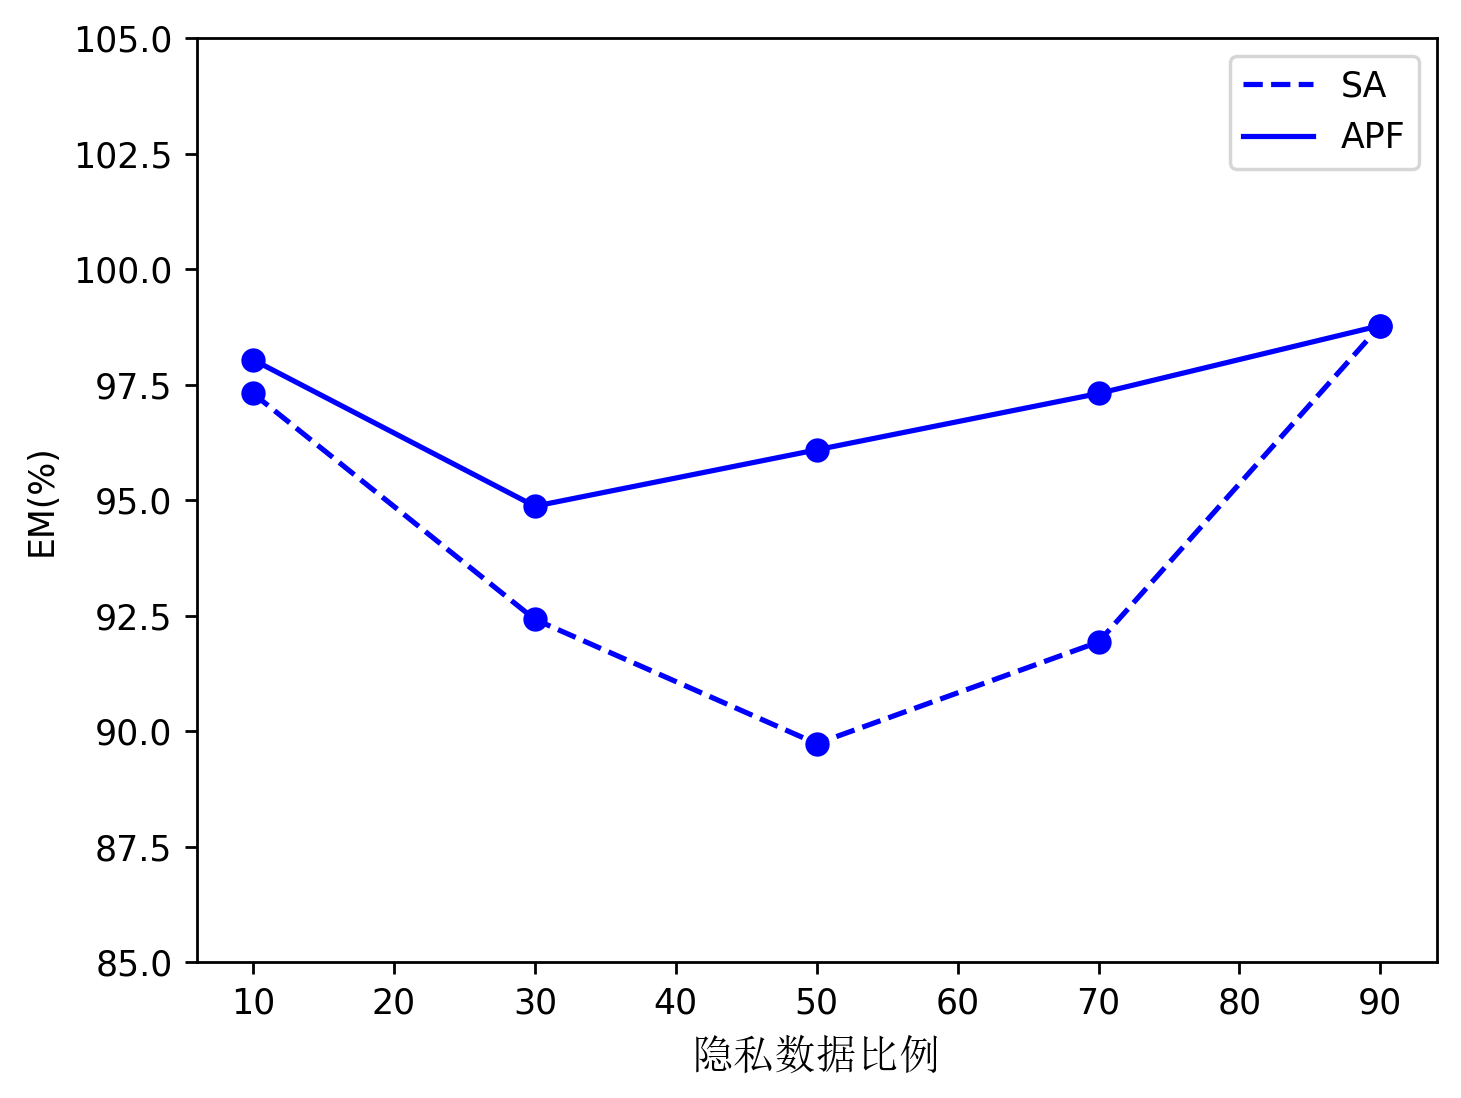

In [1]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_TQA_K10_noadapt = (
    np.array([0.97310513, 0.92420538, 0.89731051, 0.9193154, 0.98777506]).round(4) * 100
)
EM_TQA_K10 = (
    np.array([0.9804401, 0.94865526, 0.9608802, 0.97310513, 0.98777506]).round(4) * 100
)
print(EM_TQA_K10 - EM_TQA_K10_noadapt)
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_TQA_K10_noadapt, color="blue", linestyle="--", label="SA")
plt.scatter(x, EM_TQA_K10_noadapt, color="blue")
plt.plot(x, EM_TQA_K10, color="blue", label="APF")
plt.scatter(x, EM_TQA_K10, color="blue")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

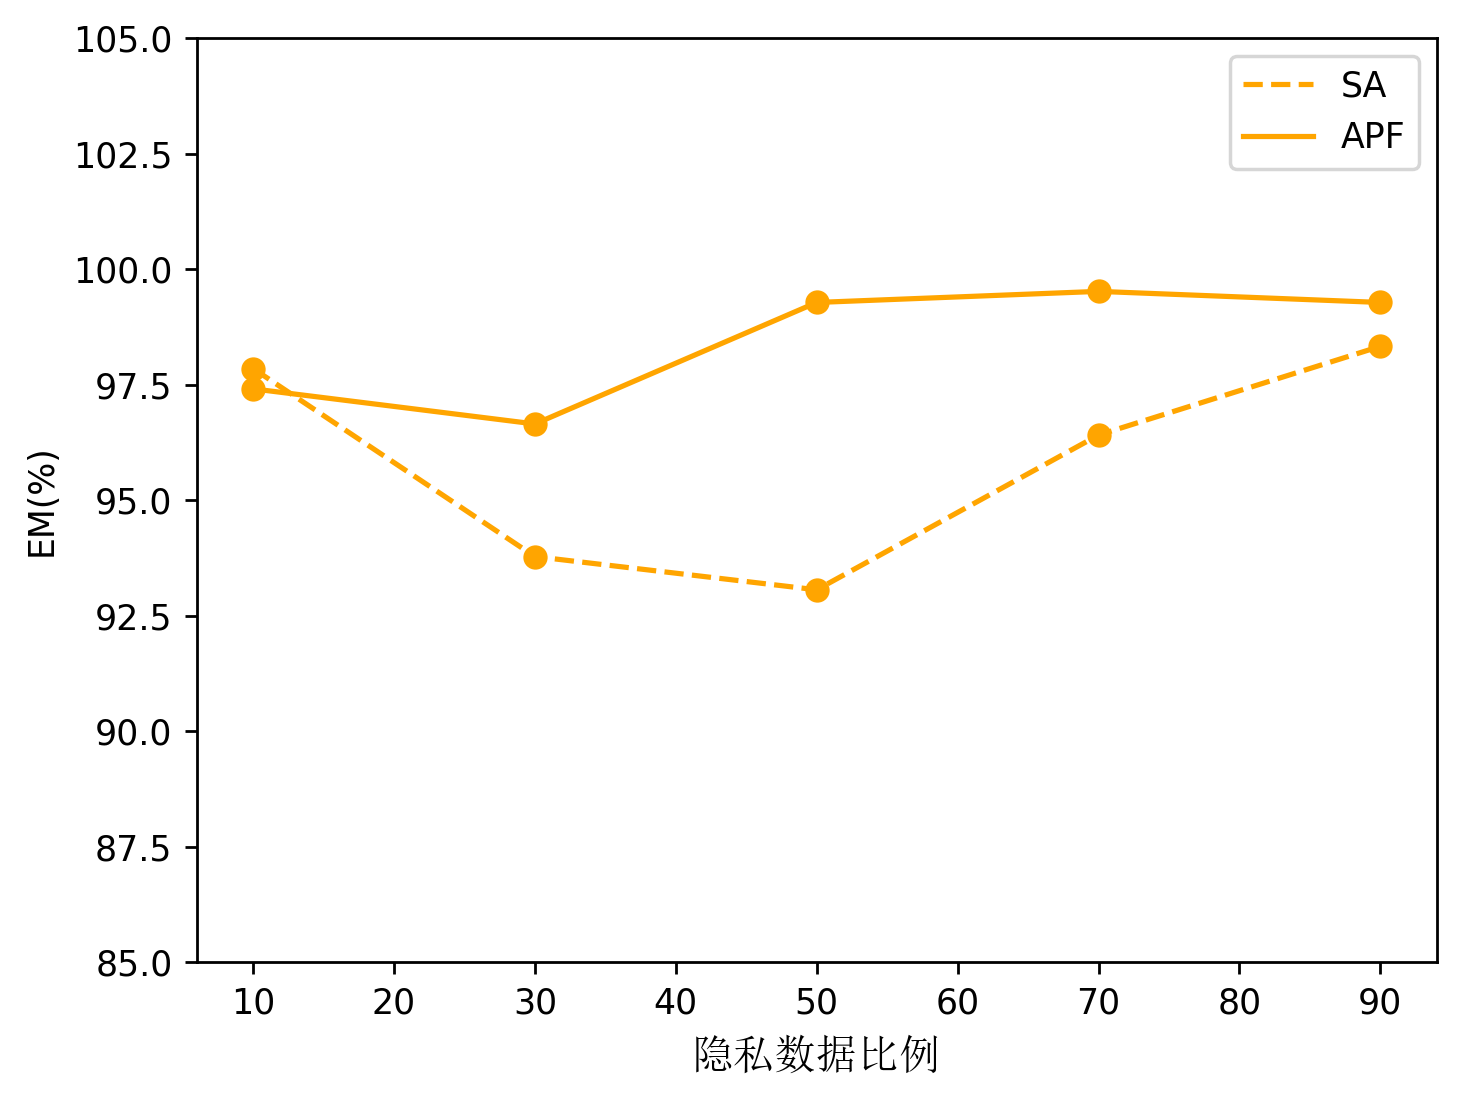

In [2]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)


EM_NQ_K10_noadapt = [97.85, 93.78, 93.06, 96.41, 98.33]
EM_NQ_K10 = [97.41, 96.65, 99.28, 99.52, 99.28]
x = np.linspace(10, 90, 5, dtype=int)
plt.figure(dpi=250)
plt.plot(x, EM_NQ_K10_noadapt, color="orange", linestyle="--", label="SA")
plt.scatter(x, EM_NQ_K10_noadapt, color="orange")
plt.plot(x, EM_NQ_K10, color="orange", label="APF")
plt.scatter(x, EM_NQ_K10, color="orange")
plt.ylim(85, 105)
plt.ylabel("EM(%)")
plt.xlabel("隐私数据比例", fontproperties=font)
plt.legend()

In [58]:
import json
import numpy as np


def fn():
    lst = []
    for th in [0.7, 0.8, 0.9]:
        path = (
            f"../archive/ch3/TestAccuracyForFiD_NQ_DEV_threshold{th}_K10_size1000.json"
        )
        fp = open(path)
        data = json.load(fp)
        fp.close()
        pfs = np.array(data["raw"]["pri_fusion_size"])
        if sum(pfs.shape) == 5000:
            # print(f"pfs\n{pfs.reshape(5, 1000).mean(-1)}")
            lst.append(pfs.reshape(5, 1000).mean(-1))
        if sum(pfs.shape) == 10000:
            # print(f"pfs\n{pfs.reshape(2, 5, 1000)[1].mean(-1)}")
            lst.append(pfs.reshape(2, 5, 1000)[1].mean(-1))
    lst = np.array(lst)
    print(((lst - [1, 3, 5, 7, 9]) / [1, 3, 5, 7, 9]) * 100)


fn()

[[ 9.5        13.96666667 10.22        3.82857143  0.67777778]
 [29.         35.66666667 18.66        6.62857143  1.08888889]
 [92.1        77.2        34.54       13.05714286  2.3       ]]


In [ ]:
import json
import numpy as np


def fn():
    # path1 = "../archive/ch3/is_adaptive_True.json"
    # path2 = "../tmp/native.json"
    path1 = "../tmp/is_adaptive_True_thre0.8_k10_s100_e.json"
    path2 = "../tmp/native_k10_s100.json"
    fp = open(path1)
    data = json.load(fp)
    fp.close()
    dt = np.array(data["raw"]["cpu_DECODER"])
    et = np.array(data["raw"]["cpu_ENCODER"])
    # prs = np.array(data["raw"]["pri_fusion_size"])
    rds = np.array(data["raw"]["required_dep_size"])
    tokens = np.array(data["raw"]["TOKENS_TEE"])
    sdt = np.array(data["raw"]["DECODER_TIMER"])
    fp = open(path2)
    data = json.load(fp)
    fp.close()
    native_et = np.array(data["raw"]["cpu_ENCODER"])
    native_dt = np.array(data["raw"]["cpu_DECODER"])

    load_size = 100

    totaltime = dt + et
    totaltime_ = totaltime.reshape(2, 5, load_size).sum(-1)
    print(f"totaltime\n{(totaltime_ / totaltime_[0])[1].round(4) * 100}")
    native_totaltime = native_et + native_dt
    native_totaltime = np.broadcast_to(native_totaltime, (2, 5, load_size))
    native_totaltime_ = native_totaltime.sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")
    mask_ = rds.reshape(2, 5, load_size) > 0
    # mask_ = ~mask_
    native_totaltime_ = np.where(mask_, native_totaltime, 0).sum(-1)
    totaltime_ = np.where(mask_, totaltime.reshape(2, 5, load_size), 0).sum(-1)
    print(f"totaltime\n{(native_totaltime_ / totaltime_).round(2)}")

    rds_ = rds.reshape(2, 5, load_size).sum(-1)
    print(f"rds\n{(rds_[1])}")

    et_ = et.reshape(2, 5, load_size).sum(-1)
    print(f"encodertime\n{et_}")
    print(f"encodertime\n{(et_ / et_[0])[1].round(4) * 100}")

    dt_ = dt.reshape(2, 5, load_size).sum(-1)
    print(f"decodertime\n{dt_}")
    print(f"decodertime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    mask_ = rds.reshape(2, 5, load_size) > 0
    dt_ = dt.reshape(2, 5, load_size)
    dt_ = np.where(mask_, dt_, 0).sum(-1)
    print(f"adpativetime\n{(dt_ / dt_[0])[1].round(4) * 100}")

    tkcum_ = (tokens - 1).cumsum()
    tkcum_ = np.insert(tkcum_, 0, 0)[:-1]
    sdt_ = sdt[tkcum_].reshape(2, 5, load_size)
    mask_ = rds.reshape(2, 5, load_size) > 0
    sdt_ = np.where(mask_, sdt_, 0).sum(-1)
    print(f"sdt_\n{sdt_}")
    print(f"sdt_\n{(sdt_ / sdt_[0])[1].round(4) * 100}")


fn()

FileNotFoundError: [Errno 2] No such file or directory: '../tmp/is_adaptive_True_k10_s100_e.json'

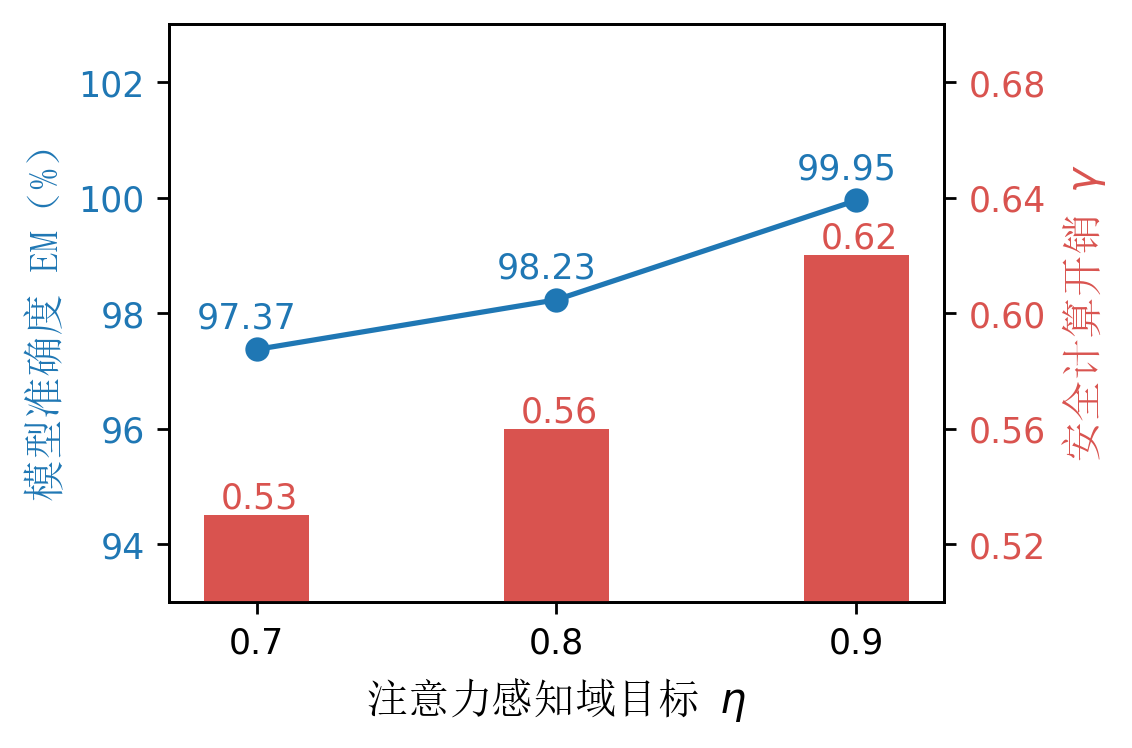

In [ ]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np

font_path = "../tmp/SimSun.ttc"
font = FontProperties(fname=font_path, size=12)

acc = [97.37, 98.23, 99.95]
eff = [0.53, 0.56, 0.62]
x = [0.7, 0.8, 0.9]

fig, ax1 = plt.subplots(figsize=(4, 3), dpi=250)

# 左轴 (Accuracy)
ax1.plot(x, acc, color="tab:blue")
ax1.scatter(x, acc, color="tab:blue")
ax1.set_ylim(93, 103)
ax1.set_ylabel("模型准确度 EM（%）", color="tab:blue", fontproperties=font)
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(x)
for a, b in zip(x, acc):
    ax1.text(a - 0.02, b + 0.38, b, color="tab:blue")

# 右轴 (Efficiency)
ax2 = ax1.twinx()
ax2.bar(x, eff, width=0.035, color="#d9534f")
ax2.set_ylim(0.5, 0.7)
ax2.set_ylabel(r"安全计算开销 $\gamma$", color="#d9534f", fontproperties=font)
ax2.tick_params(axis="y", labelcolor="#d9534f")
ax2.yaxis.set_major_locator(MaxNLocator(5))

for a, b in zip(x, eff):
    ax2.text(a - 0.012, b + 0.0025, b, color="#d9534f")

ax1.set_xlabel(r"注意力感知域目标 $\eta$", fontproperties=font)
plt.show()

149.2936323628281 -0.11846653620400718


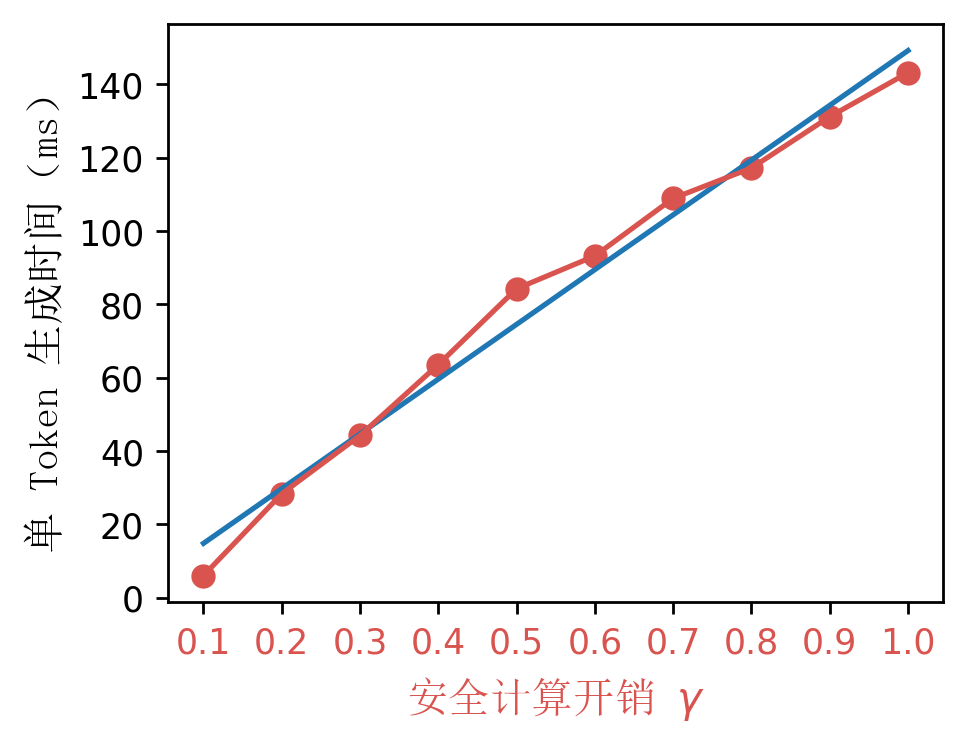

In [ ]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np


def fn():
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)
    x = np.linspace(0.1, 1, 10)
    y = (
        np.array(
            [
                0.6031293869018555,
                2.833322525024414,
                4.423059940338135,
                6.356080055236816,
                8.42396068572998,
                9.319085836410522,
                10.88877248764038,
                11.715913772583008,
                13.114457607269287,
                14.315248966217041,
            ]
        )
        * 10
    )
    a, b = np.polyfit(x, y, 1)
    print(a, b)
    plt.figure(figsize=(4, 3), dpi=250)
    plt.plot(x, [a * i + b for i in x])
    plt.plot(x, y, color="#d9534f")
    plt.scatter(x, y, color="#d9534f")
    plt.xticks(x)
    plt.tick_params(axis="x", labelcolor="#d9534f")
    plt.ylabel("单 Token 生成时间（ms）", fontproperties=font)
    plt.xlabel(r"安全计算开销 $\gamma$", fontproperties=font, color="#d9534f")


fn()

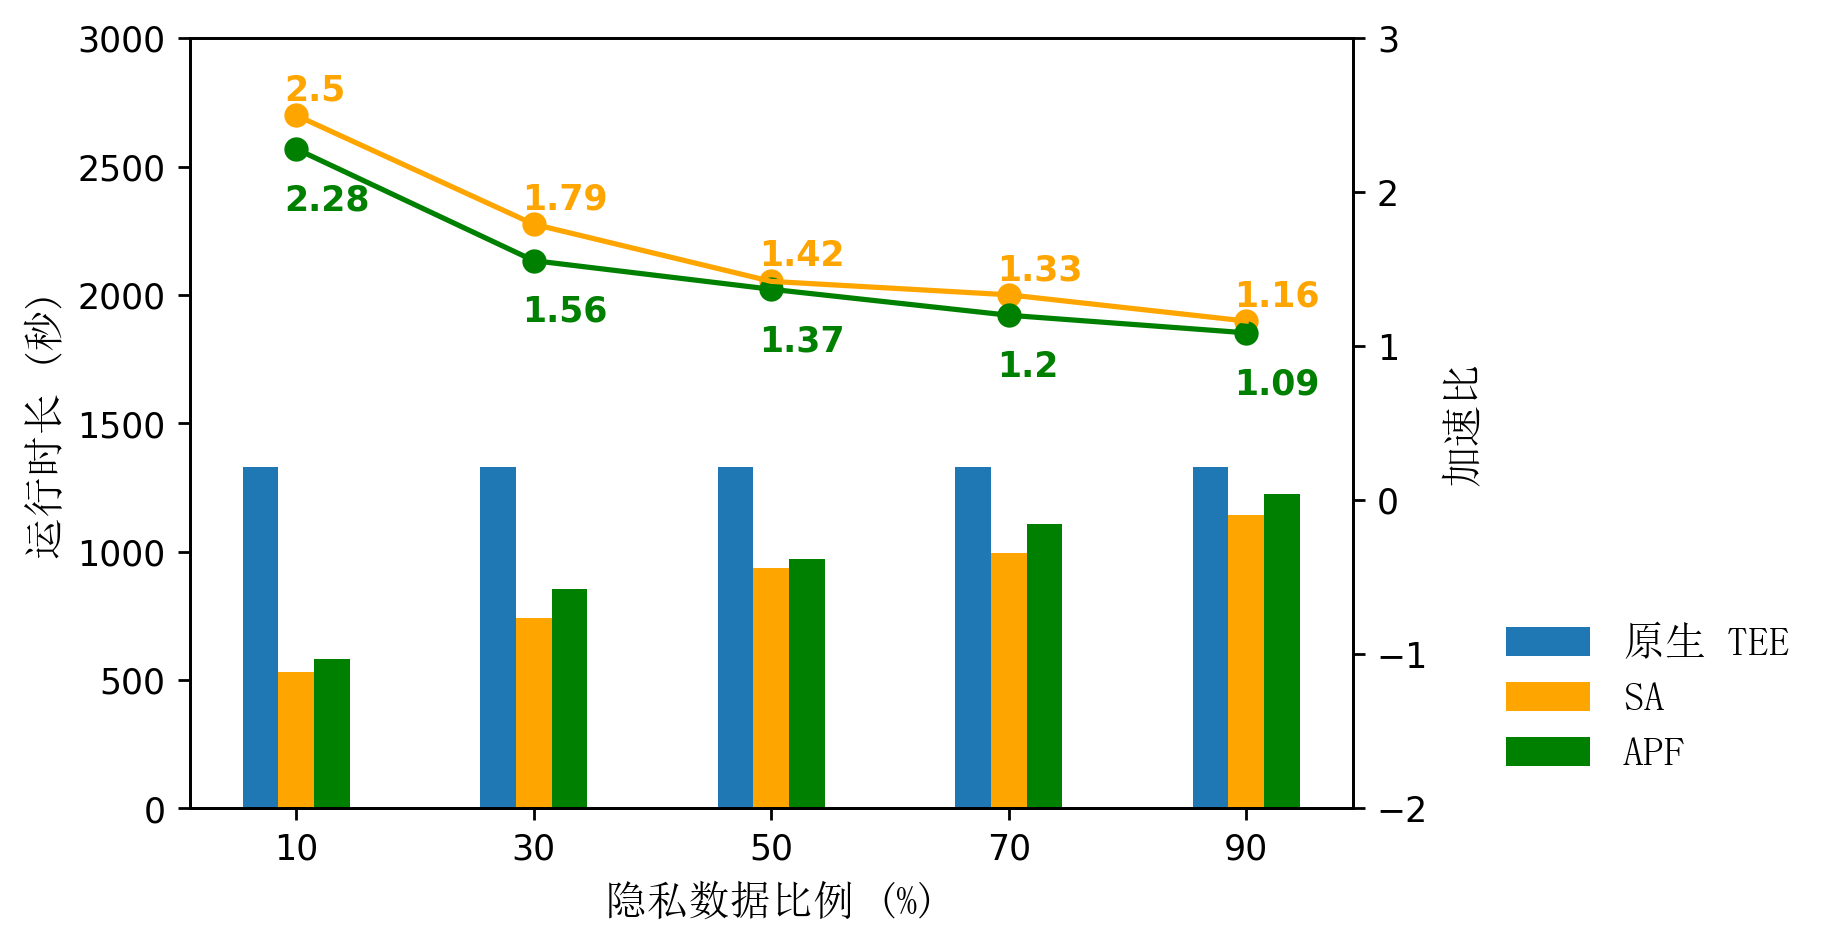

In [87]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np


def fn():
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)
    split_runtime = (
        np.array(
            [
                53.176180362701416,
                74.14553833007812,
                93.51531720161438,
                99.62183976173401,
                114.22109889984131,
            ]
        )
        * 10
    )
    thre08_runtime = (
        np.array(
            [
                58.25966715812683,
                85.42069292068481,
                97.00310826301575,
                110.63439416885376,
                122.25168251991272,
            ]
        )
        * 10
    )
    native_runtime = 132.87076044082642 * 10
    x = np.linspace(10, 90, 5, dtype=int)
    plt.figure(figsize=(6, 4), dpi=250)
    plt.bar(
        x - 3,
        [native_runtime for _ in x],
        width=3,
        label="原生 TEE",
    )
    plt.bar(x, split_runtime, width=3, color="orange", label="SA")
    plt.bar(x + 3, thre08_runtime, width=3, color="green", label="APF")
    plt.xticks(x)
    plt.xlabel("隐私数据比例 (%)", fontproperties=font)
    plt.ylim(0, 3000)
    plt.ylabel("运行时长 (秒)", fontproperties=font)
    plt.legend(
        loc="lower left", bbox_to_anchor=(1.1, 0), ncol=1, prop=font, frameon=False
    )

    ax2 = plt.twinx()
    ax2.plot(x, native_runtime / split_runtime, color="orange")
    ax2.scatter(x, native_runtime / split_runtime, color="orange")
    for a, b in zip(x, (native_runtime / split_runtime).round(2)):
        plt.text(a - 1, b + 0.1, b, weight="bold", color="orange")
    ax2.plot(x, native_runtime / thre08_runtime, color="green")
    ax2.scatter(x, native_runtime / thre08_runtime, color="green")
    for a, b in zip(x, (native_runtime / thre08_runtime).round(2)):
        plt.text(a - 1, b - 0.4, b, weight="bold", color="green")
    # ax2.set_yticks([1, 2, 3])
    ax2.set_ylim(-2, 3)
    ax2.set_ylabel("加速比", fontproperties=font)


fn()

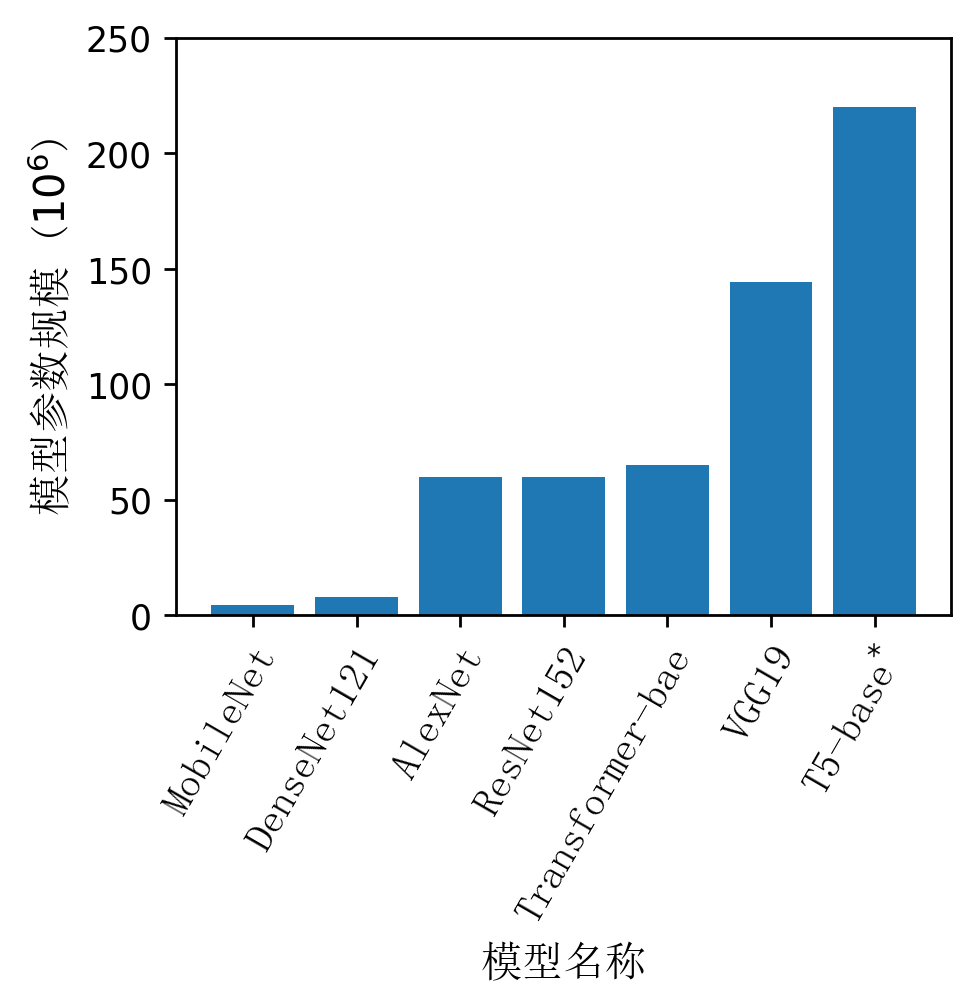

In [53]:
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np


def fn():
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)

    x = [
        "AlexNet",
        "VGG19",
        "ResNet152",
        "DenseNet121",
        "MobileNet",
        "Transformer-bae",
        r"T5-base$^{*}$",
    ]
    x = np.array(x)

    y = [60, 144, 60, 8, 4.2, 65, 220]
    y = np.array(y)

    idx = np.argsort(y)
    x = x[idx]
    y = y[idx]

    plt.figure(figsize=(4,3), dpi=250)
    plt.bar(x, y)
    plt.ylim(0, 250)
    plt.ylabel(r"模型参数规模 ($10^6$)", fontproperties=font)
    plt.xlabel("模型名称", fontproperties=font)
    plt.xticks(rotation=60, ha="right", rotation_mode="anchor", fontproperties=font)

fn()

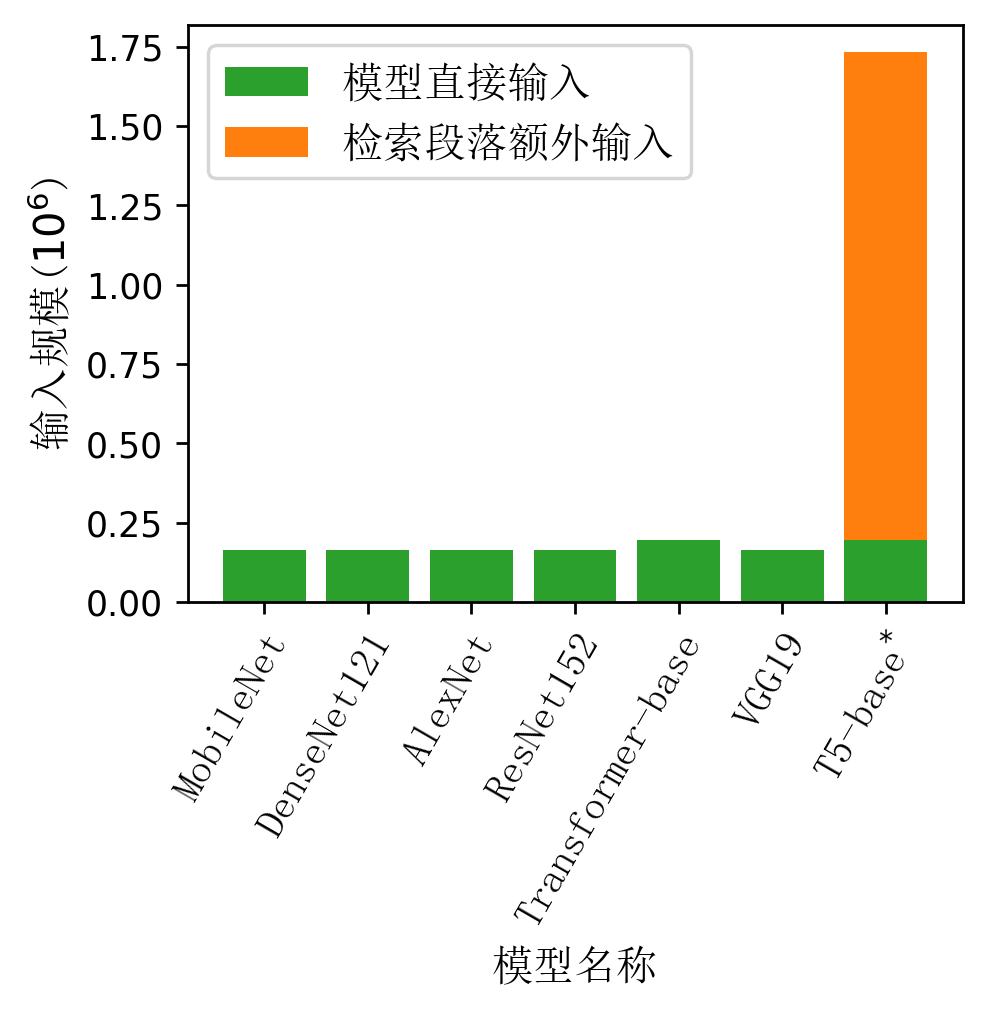

In [54]:
from turtle import color

from matplotlib.font_manager import FontProperties
from matplotlib.ticker import MaxNLocator

import matplotlib.pyplot as plt
import numpy as np


def fn():
    font_path = "../tmp/SimSun.ttc"
    font = FontProperties(fname=font_path, size=12)

    x = [
        "AlexNet",
        "VGG19",
        "ResNet152",
        "DenseNet121",
        "MobileNet",
        "Transformer-base",
        r"T5-base$^{*}$",
    ]
    x = np.array(x)

    a = 224 * 244 * 3
    y = [a, a, a, a, a, 256 * 768, 256 * 768]
    y = np.array(y)

    y_ = [60, 144, 60, 8, 4.2, 65, 220]
    y_ = np.array(y_)
    idx = np.argsort(y_)
    x = x[idx]
    y = y[idx] / 10 ** 6

    plt.figure(figsize=(4, 3), dpi=250)
    plt.bar(x, y, color="tab:green", label="模型直接输入")
    plt.bar(
        r"T5-base$^{*}$",
        10 * 200 * 768 / (10 ** 6),
        bottom=256 * 768 / (10 ** 6),
        color="tab:orange",
        label="检索段落额外输入",
    )
    plt.ylabel(r"输入规模($10^6$)", fontproperties=font)
    plt.xlabel("模型名称", fontproperties=font)
    plt.xticks(rotation=60)
    plt.legend(prop=font)
    plt.xticks(rotation=60, ha="right", rotation_mode="anchor", fontproperties=font)


fn()